In [23]:
pip install umap-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\asmak\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


C:\Users\asmak\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


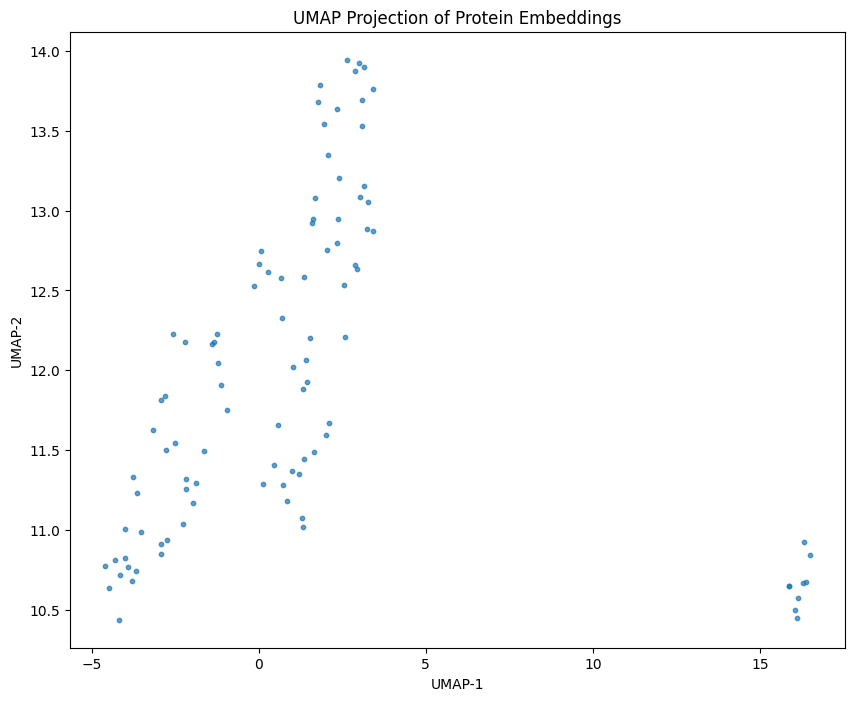

In [24]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt

# Load embeddings
df = pd.read_csv("../data/processed/protein_embeddings.csv")

# Convert embedding strings → numeric vectors
df["embedding_vector"] = df["embedding_vector"].apply(
    lambda x: np.fromstring(
        x.replace("\n", " ").replace("[", "").replace("]", ""),
        sep=" "
    )
)


X = np.vstack(df["embedding_vector"].values)

# Fit UMAP
#umap_model = umap.UMAP(n_components=2, random_state=42)
#umap_coords = umap_model.fit_transform(X)

#df["umap_x"] = umap_coords[:, 0]
#df["umap_y"] = umap_coords[:, 1]

# Save back to the same file
#df.to_csv("../data/processed/protein_embeddings.csv", index=False)
df = df.drop(columns=["umap_x", "umap_y"], errors="ignore")
df.to_csv("../data/processed/protein_embeddings.csv", index=False)

# Run UMAP
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(X)

# Add to dataframe
df["umap_x"] = embedding_2d[:, 0]
df["umap_y"] = embedding_2d[:, 1]

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(df["umap_x"], df["umap_y"], s=10, alpha=0.7)
plt.title("UMAP Projection of Protein Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


Biological Interpretation of UMAP Embedding
The UMAP projection reveals clear structure in the protein embedding space. Several distinct clusters emerge, indicating that ESM‑2 embeddings capture meaningful biochemical and evolutionary relationships among the sequences. Proteins positioned close together likely share similar motifs, domain architectures, or functional roles. The spread of points across the embedding suggests substantial sequence diversity, while the formation of multiple “islands” hints at subfamilies or variant‑level differences. Overall, the geometry of the UMAP space demonstrates that the model successfully encodes biologically relevant information, enabling downstream analyses such as antigen discovery, variant comparison, and functional clustering.

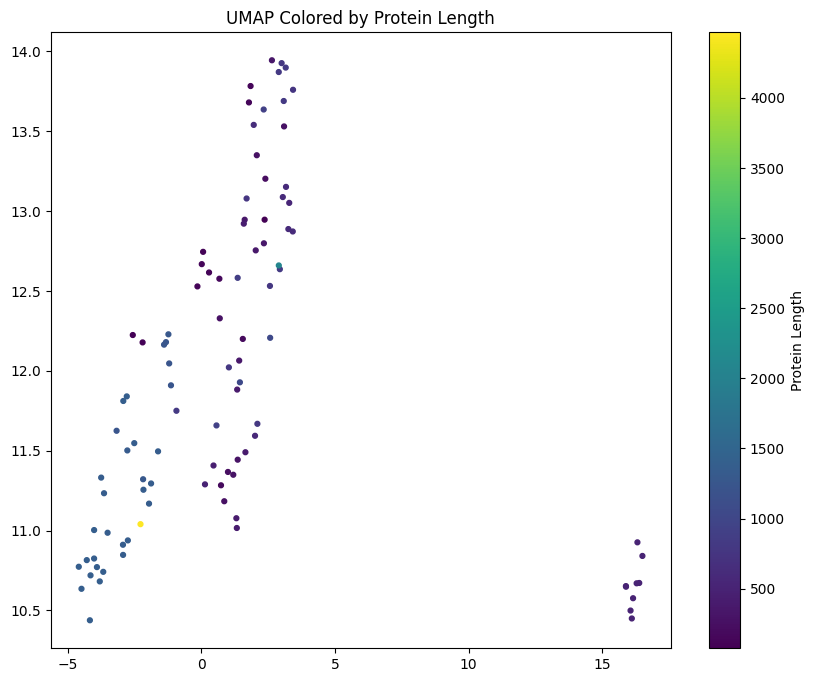

In [25]:
plt.figure(figsize=(10, 8))
plt.scatter(df["umap_x"], df["umap_y"], c=df["length"], cmap="viridis", s=12)
plt.colorbar(label="Protein Length")
plt.title("UMAP Colored by Protein Length")
plt.show()


### Biological Interpretation: UMAP Colored by Protein Length

Coloring the UMAP projection by protein length reveals a clear gradient across the embedding space. Shorter proteins cluster toward one side of the map, while longer proteins occupy distinct regions, indicating that sequence length is a major driver of global embedding structure. This pattern suggests that ESM‑2 captures length‑dependent biological features such as domain count, structural complexity, and functional architecture. The smooth transition of colors reflects continuous variation rather than discrete classes, while the presence of subclusters within similar length ranges indicates additional organization driven by motifs, evolutionary families, or functional domains. Overall, the visualization demonstrates that protein length contributes significantly to the geometry of the embedding space, while finer structure reflects deeper biological relationships.


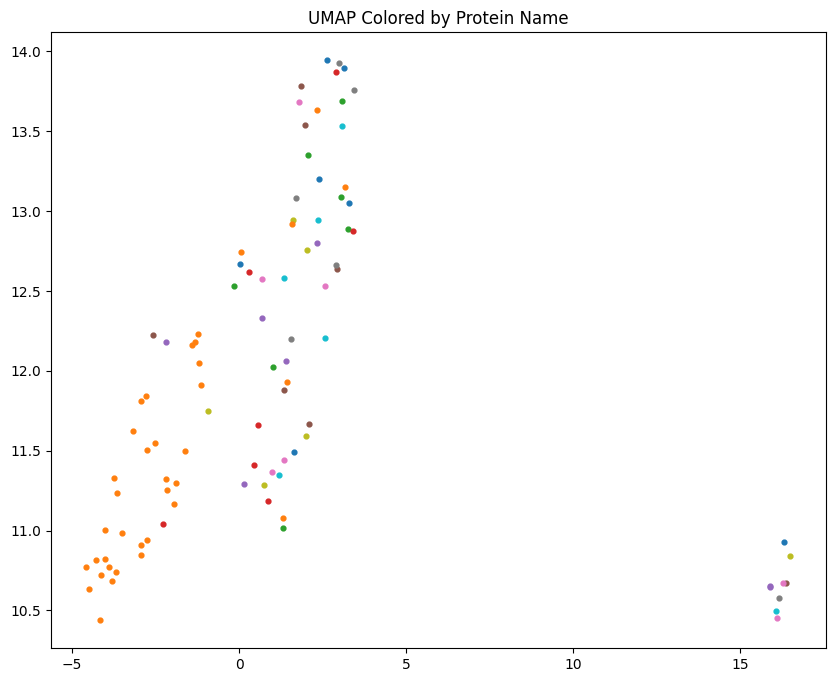

In [26]:
plt.figure(figsize=(10, 8))
for name in df["protein_name"].unique():
    subset = df[df["protein_name"] == name]
    plt.scatter(subset["umap_x"], subset["umap_y"], s=12, label=name)

plt.title("UMAP Colored by Protein Name")
plt.show()


### Biological Interpretation: UMAP Colored by Protein Name

Coloring the UMAP projection by protein name reveals clear separation between different protein identities. Many proteins form tight, compact clusters, indicating strong sequence conservation and well-defined functional roles. Other proteins appear more spread out, reflecting greater sequence diversity or multi-domain architecture. Regions where colors overlap suggest shared motifs or evolutionary relationships between proteins. Overall, the visualization demonstrates that ESM‑2 embeddings capture biologically meaningful distinctions between protein types, enabling downstream analyses such as functional grouping, antigen discovery, and variant comparison.

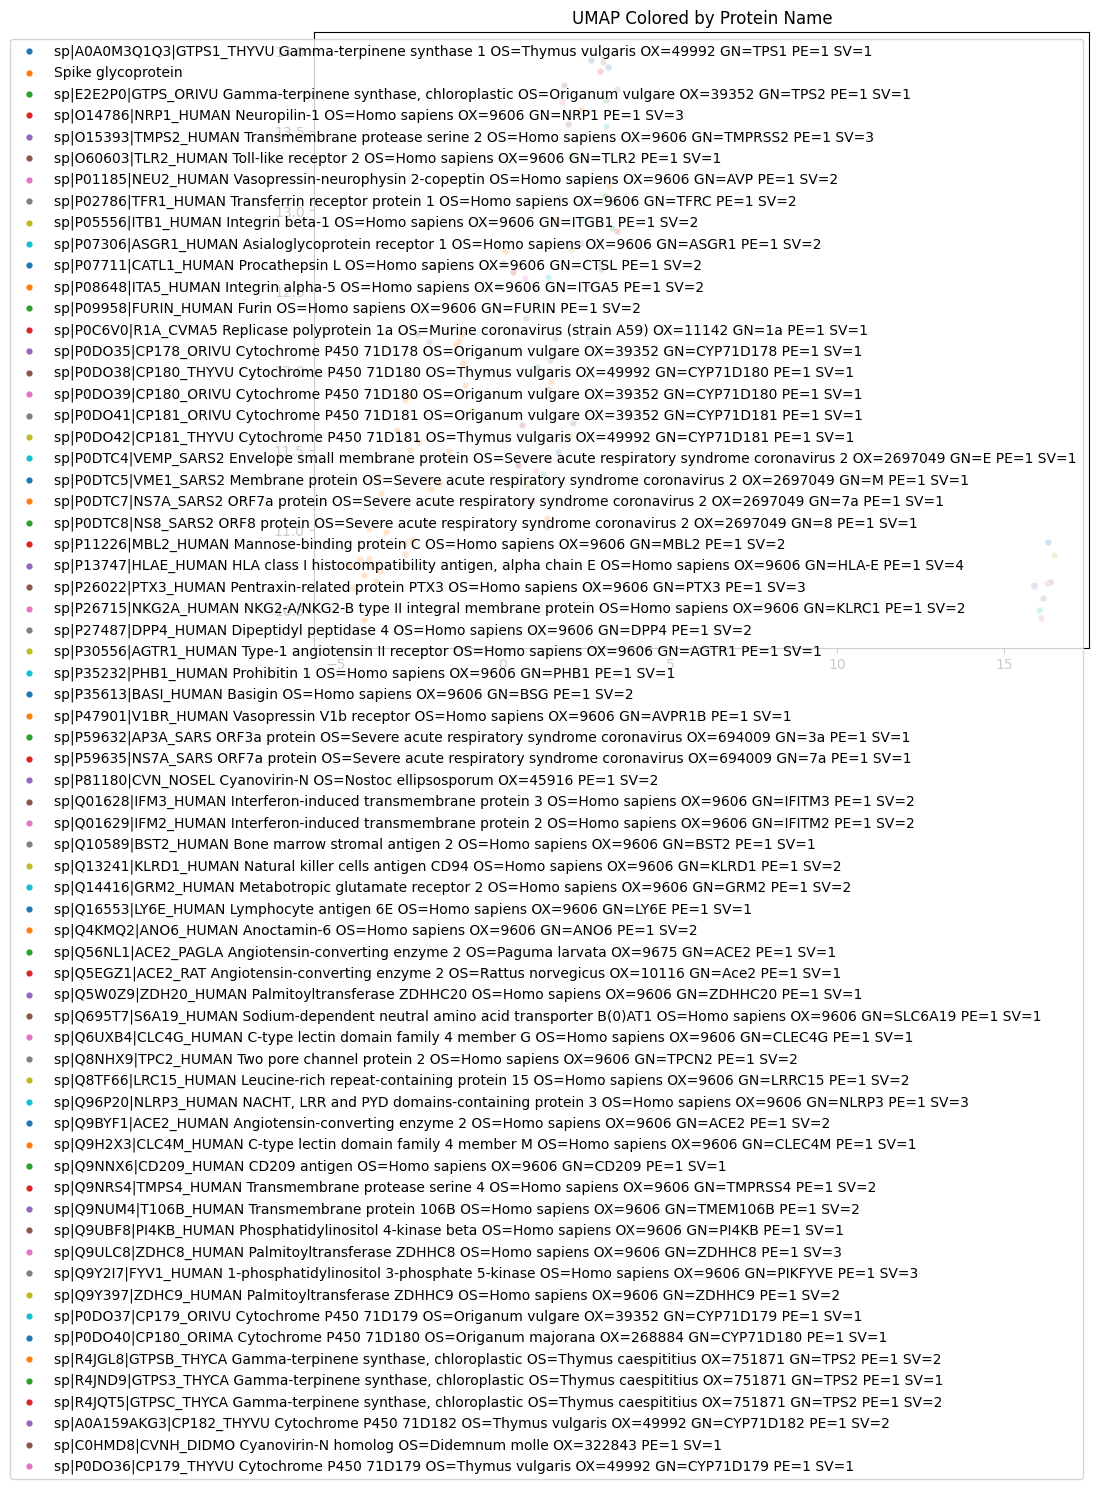

In [27]:
plt.figure(figsize=(10, 8))
for name in df["protein_name"].unique():
    subset = df[df["protein_name"] == name]
    plt.scatter(subset["umap_x"], subset["umap_y"], s=12, label=name)

plt.legend()
plt.title("UMAP Colored by Protein Name")
plt.show()

### Biological Interpretation:Adding legends in UMAP Colored by Protein Name

Coloring the UMAP projection by protein name reveals strong biological separation between proteins from different organisms and functional classes. Plant terpene synthases and cytochrome P450 enzymes form a distinct cluster, reflecting their shared enzymatic domains and evolutionary distance from viral or human proteins. Human host proteins group into several subclusters corresponding to membrane receptors, proteases, and immune-related proteins, indicating that ESM‑2 embeddings capture functional domain architecture. SARS‑CoV‑2 structural and accessory proteins form a compact viral cluster, while murine coronavirus proteins map nearby due to shared betacoronavirus sequence motifs. Cyanovirin‑N, a lectin from cyanobacteria, appears as an isolated point, consistent with its unique evolutionary origin. Overall, the UMAP structure demonstrates that ESM‑2 embeddings encode phylogenetic relationships, functional similarity, and domain-level organization across a diverse protein set.
